DAG made from the data imported from the file- "gen_new_test_causal_continous_data.ipynb"

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from dowhy import CausalModel
from castle.algorithms import PC
from castle.common import GraphDAG

c:\Users\gk442\AppData\Local\miniconda3\envs\causal\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-08-04 10:15:09,160 - c:\Users\gk442\AppData\Local\miniconda3\envs\causal\Lib\site-packages\castle\backend\__init__.py[line:36] - INFO: You can use `os.environ['CASTLE_BACKEND'] = backend` to set the backend(`pytorch` or `mindspore`).
2026-08-04 10:15:09,219 - c:\Users\gk442\AppData\Local\miniconda3\envs\causal\Lib\site-packages\castle\algorithms\__init__.py[line:36] - INFO: You are using ``pytorch`` as the backend.


In [2]:
df = pd.read_csv ("final_new_gen_data_10000.csv")

In [3]:
df.describe()

,A,B,C,D,E,Treatment,Outcome
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,-0.252136,0.197864,-0.692136,0.740100,0.897864,0.710800,3.826009
std,1.003462,1.003462,1.003462,0.438601,1.003462,0.453414,2.618959
min,-4.172400,-3.722400,-4.612400,0.000000,-3.022400,0.000000,-2.947868
25%,-0.922591,-0.472591,-1.362591,0.000000,0.227409,0.000000,0.791728
50%,-0.252595,0.197405,-0.692595,1.000000,0.897405,1.000000,4.983472
75%,0.421081,0.871081,-0.018919,1.000000,1.571081,1.000000,5.711122
max,3.676238,4.126238,3.236238,1.000000,4.826238,1.000000,8.570540


In [4]:
pc = PC()

pc.learn(df)

c:\Users\gk442\AppData\Local\miniconda3\envs\causal\Lib\site-packages\castle\common\independence_tests.py:86: RuntimeWarning: divide by zero encountered in scalar divide
  r = -1 * PM[0, 1] / math.sqrt(abs(PM[0, 0] * PM[1, 1]))


In [5]:
pc.causal_matrix

Tensor([[0, 0, 1, 0, 1, 0, 0],
        [0, 0, 1, 0, 1, 0, 0],
        [0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 1],
        [1, 1, 1, 0, 0, 0, 0],
        [0, 0, 0, 1, 0, 0, 1],
        [0, 0, 0, 1, 0, 1, 0]])

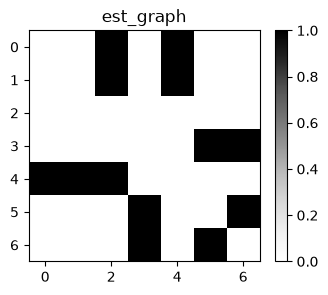

In [6]:
GraphDAG(est_dag=pc.causal_matrix)

In [7]:
import utils_causal

nodes = df.columns
labels = nodes

nodes_labels = [(n, n) for n in nodes]

edges = []
for i, start_node in enumerate(nodes):
    for j, end_node in enumerate(nodes):
        if pc.causal_matrix[i, j] == 1:
            edges.append((start_node, end_node))

2026-08-04 10:15:09,606 - c:\Users\gk442\AppData\Local\miniconda3\envs\causal\Lib\site-packages\dowhy\causal_model.py[line:506] - INFO: Model to find the causal effect of treatment ['Treatment'] on outcome ['Outcome']
2026-08-04 10:15:09,606 - c:\Users\gk442\AppData\Local\miniconda3\envs\causal\Lib\site-packages\dowhy\utils\plotting.py[line:84] - INFO: Pygraphviz installation not found, falling back to networkx plotting. For better looking plots, consider installing pygraphviz. Note This requires both the Python pygraphviz package (``pip install pygraphviz``) and the shared system library (e.g. ``brew install graphviz`` or ``apt-get install graphviz``)


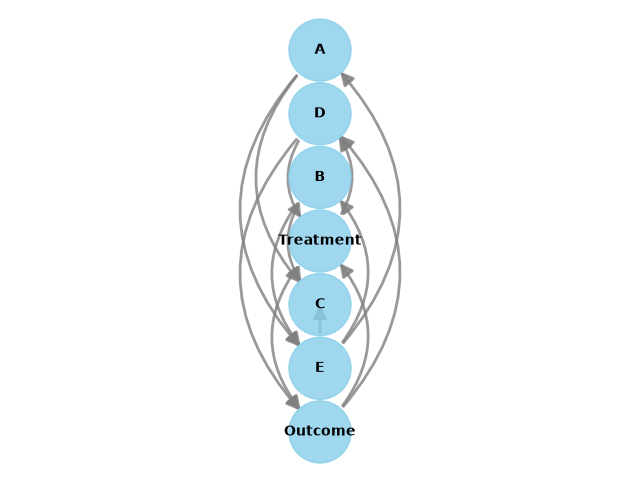

In [8]:
model_test = utils_causal.make_causalmodel_object(nodes_labels, edges)
model_test.view_model()

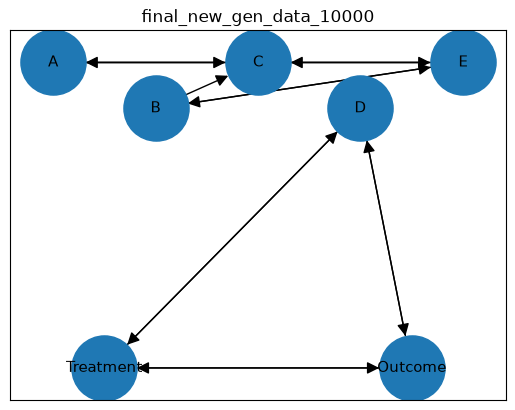

In [10]:
adj_matrix= np.array(pc.causal_matrix)

node_names=df.columns

G=nx.from_numpy_array(adj_matrix, create_using=nx.DiGraph)

mapping={i:node_names[i] for i in range(len(node_names))}
G=nx.relabel_nodes(G, mapping)

pos={
    "A":(1,1),
    "B":(2,0.85),
    "C":(3,1),
    "D":(4,0.85),
    "E":(5,1),
    "Treatment":(1.5,0),
    "Outcome":(4.5,0)
}

nx.draw_networkx(
    G,
    pos,
    with_labels=True,
    arrows=True,
    node_size=2200,
    font_size=11,
    arrowsize=18
)

plt.title("final_new_gen_data_10000")
plt.savefig("final_new_gen_data_10000.png")
plt.show()